In [1]:
import pandas as pd

df = pd.read_csv('Maternal Health Risk Data Set.csv')

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [2]:
import numpy as np

print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Number of duplicates: {df.duplicated().sum()}")

print("\n--- Statistical Summary ---")
display(df.describe())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB

--- Missing Values ---
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

--- Duplicate Rows ---
Number of duplicates: 562

--- Statistical Summary ---


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


/tmp/ipykernel_3590/2125903932.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], palette='viridis')


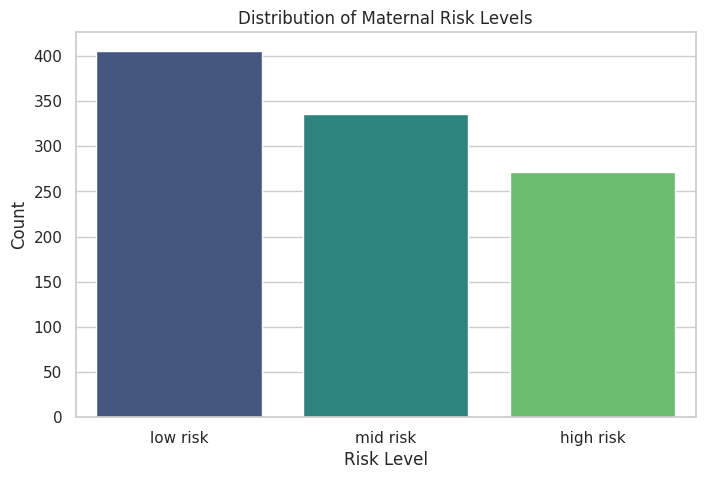

/tmp/ipykernel_3590/2125903932.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'], palette='Set2')


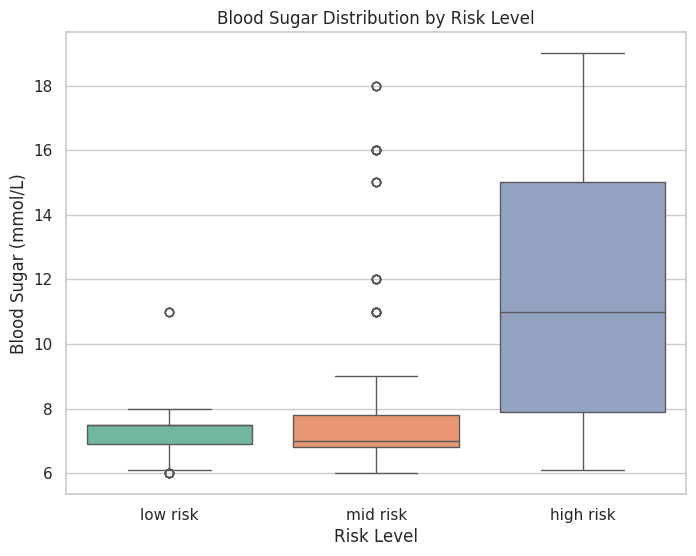

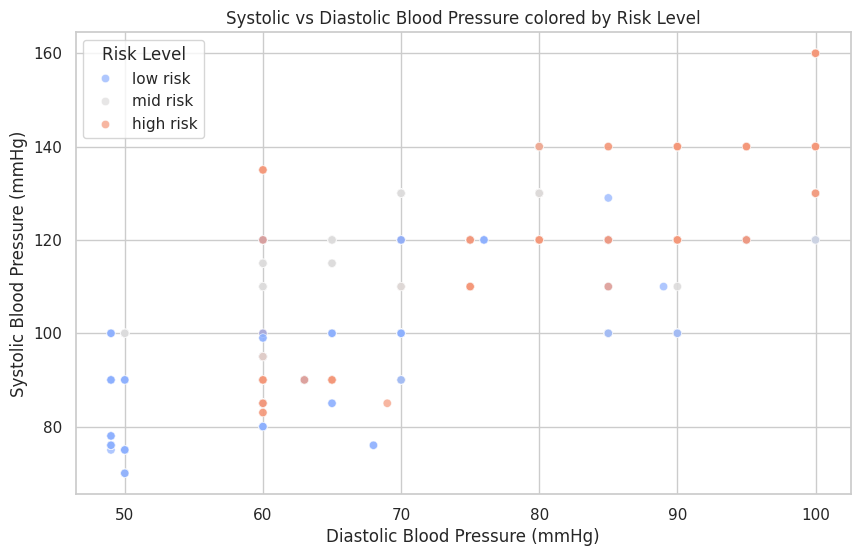

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots
sns.set_theme(style="whitegrid")

# 1. Distribution of Risk Level (Answers part of Q1)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], palette='viridis')
plt.title('Distribution of Maternal Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()
# Interpretation for report: This chart shows the count of patients in each risk category.

# 2. Blood Sugar Comparison across Risk Groups (Answers part of Q2)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'], palette='Set2')
plt.title('Blood Sugar Distribution by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Blood Sugar (mmol/L)')
plt.show()
# Interpretation for report: This boxplot compares blood sugar levels. Noticeably, the High Risk group tends to have a higher median and wider spread of blood sugar values.

# 3. Systolic vs Diastolic Blood Pressure Scatter (Answers part of Q2/Q5 visual requirement)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='DiastolicBP', y='SystolicBP', hue='RiskLevel',
                hue_order=['low risk', 'mid risk', 'high risk'], palette='coolwarm', alpha=0.7)
plt.title('Systolic vs Diastolic Blood Pressure colored by Risk Level')
plt.xlabel('Diastolic Blood Pressure (mmHg)')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.legend(title='Risk Level')
plt.show()
# Interpretation for report: This scatterplot shows the relationship between Systolic and Diastolic BP. High risk patients tend to cluster in the higher ranges of both measurements.

--- Classification Report ---
              precision    recall  f1-score   support

   high risk       0.94      0.84      0.88        55
    low risk       0.57      0.98      0.72        81
    mid risk       0.62      0.15      0.24        67

    accuracy                           0.67       203
   macro avg       0.71      0.65      0.62       203
weighted avg       0.69      0.67      0.61       203



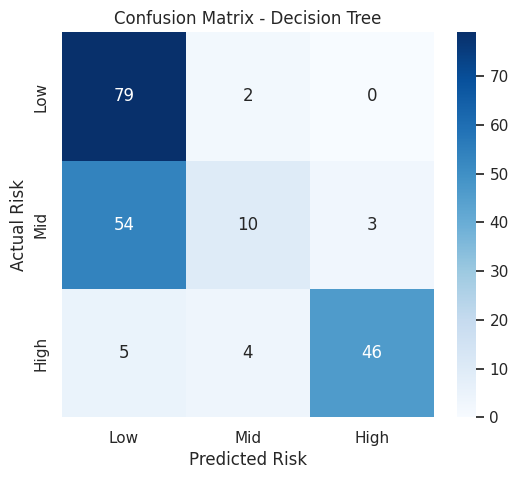

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Preparation
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Split data (80% train, 20% test) with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Build a Simple Baseline Model (Shallow Decision Tree)
# max_depth=3 prevents the model from becoming too complex
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# 3. Predictions
y_pred = tree_model.predict(X_test)

# 4. Class-wise Evaluation (Answers Q5)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix Visualization (4th Required Figure)
cm = confusion_matrix(y_test, y_pred, labels=['low risk', 'mid risk', 'high risk'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Mid', 'High'],
            yticklabels=['Low', 'Mid', 'High'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.show()

# Interpretation for report: The confusion matrix helps us see exactly where the model fails.
# Missing a 'High Risk' patient (predicting them as Low/Mid) is a critical false negative.

/tmp/ipykernel_3590/1488633270.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


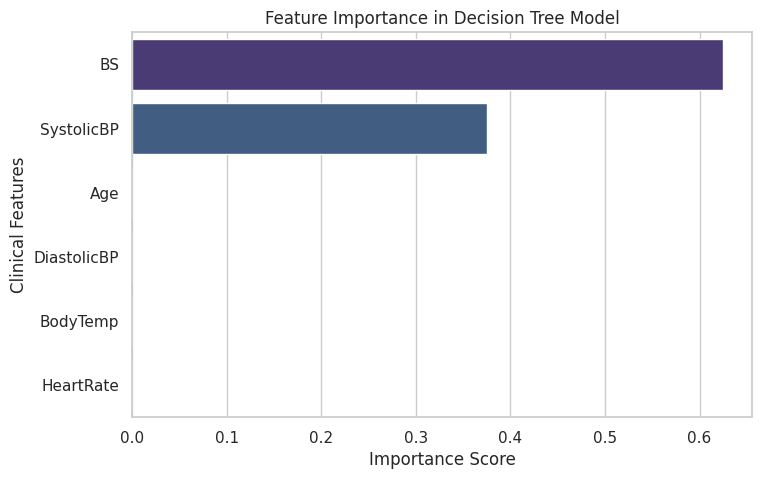

In [5]:
import pandas as pd

# 6. Feature Importance Plot (5th Required Figure - Answers Q7)
importances = tree_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Features')
plt.show()

# Interpretation for report: This chart identifies which measurements (e.g., Blood Sugar or Age)
# drive the model's predictions the most. Note: This does not prove clinical causation.